In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)


In [24]:
# Read in all CSV files and print out the number of rows and columns in each file
base_path = 'mhn predictive dataset/MHN_Dataset/'

df_admin = pd.read_csv(base_path + 'admissions.csv')
df_dic = pd.read_csv(base_path + 'data_dictionary.csv')
df_diagnoses = pd.read_csv(base_path + 'diagnoses.csv')
df_edvisit = pd.read_csv(base_path + 'ed_visits.csv')
df_lab = pd.read_csv(base_path + 'lab_results.csv')
df_med = pd.read_csv(base_path + 'medications.csv')
df_patient = pd.read_csv(base_path + 'patients.csv')
df_readmission = pd.read_csv(base_path + 'readmissions.csv')
df_vitals = pd.read_csv(base_path + 'vitals.csv')

In [25]:
# Load the preprocessed master dataset
master_df = pd.read_csv("model/master_dataset.csv", low_memory=False)
print(f"Master dataset: {master_df.shape[0]:,} rows × {master_df.shape[1]} columns")
master_df.head()


Master dataset: 8,500 rows × 110 columns


,admission_id,patient_id,admission_date,discharge_date,length_of_stay_days,admission_type,admission_source,hospital,ward,primary_diagnosis_icd,...,registered_date,age_group,total_comorbidities,is_high_comorbidity,is_high_utiliser,low_social_support,num_ed_visits,num_ed_admissions,avg_ed_wait_minutes,avg_ed_los_minutes
0,ADM-0000001,PAT-004458,2022-10-03,2022-10-12,9,Emergency,Physician Referral,MHN Cambridge,Geriatrics,N18.3,...,2018-03-28,50-64,5,1,1,0,0.0,0.0,NaN,NaN
1,ADM-0000002,PAT-001044,2023-06-24,2023-06-30,6,Urgent,Transfer,MHN Quincy,Cardiology,I10,...,2020-07-22,80+,4,1,1,0,1.0,0.0,43.0,177.0
2,ADM-0000003,PAT-000197,2024-07-16,2024-07-19,3,Observation,Transfer,MHN Fenway,ICU,I21.9,...,2020-12-03,65-79,2,1,0,0,0.0,0.0,NaN,NaN
3,ADM-0000004,PAT-001374,2020-06-23,2020-06-29,6,Emergency,Direct Admission,MHN Cambridge,Orthopedics,I63.9,...,2021-11-28,50-64,4,1,1,0,0.0,0.0,NaN,NaN
4,ADM-0000005,PAT-004116,2020-07-13,2020-07-17,4,Elective,Physician Referral,MHN Fenway,Respiratory,S72.001,...,2017-09-04,50-64,1,0,0,0,0.0,0.0,NaN,NaN


In [ ]:
#list all columns with null values and sum the number of null values in each column
null_counts = master_df.isnull().sum()

# Healthcare Intelligence — Exploratory Data Analysis

---
## 1. Dataset Overview


In [26]:
# --- Schema & Types ---
print("=== Shape ===")
print(f"{master_df.shape[0]:,} rows  ×  {master_df.shape[1]} columns\n")

print("=== Column dtypes ===")
dtype_summary = master_df.dtypes.reset_index()
dtype_summary.columns = ["Column", "dtype"]
print(dtype_summary.to_string(index=False))


=== Shape ===
8,500 rows  ×  110 columns

=== Column dtypes ===
                    Column   dtype
              admission_id  object
                patient_id  object
            admission_date  object
            discharge_date  object
       length_of_stay_days   int64
            admission_type  object
          admission_source  object
                  hospital  object
                      ward  object
     primary_diagnosis_icd  object
    primary_diagnosis_desc  object
                  drg_code   int64
              icu_admitted   int64
                  icu_days   int64
         surgery_performed   int64
            num_procedures   int64
    attending_physician_id  object
     discharge_disposition  object
         total_charges_usd float64
        insurance_paid_usd float64
     readmitted_within_30d   int64
        readmission_reason  object
            admission_year   int64
           admission_month   int64
       admission_dayofweek   int64
      is_weekend_admission

Columns with missing values: 3 / 110

                     Missing Count  Missing %
readmission_reason            6687      78.67
avg_ed_wait_minutes           3165      37.24
avg_ed_los_minutes            3165      37.24


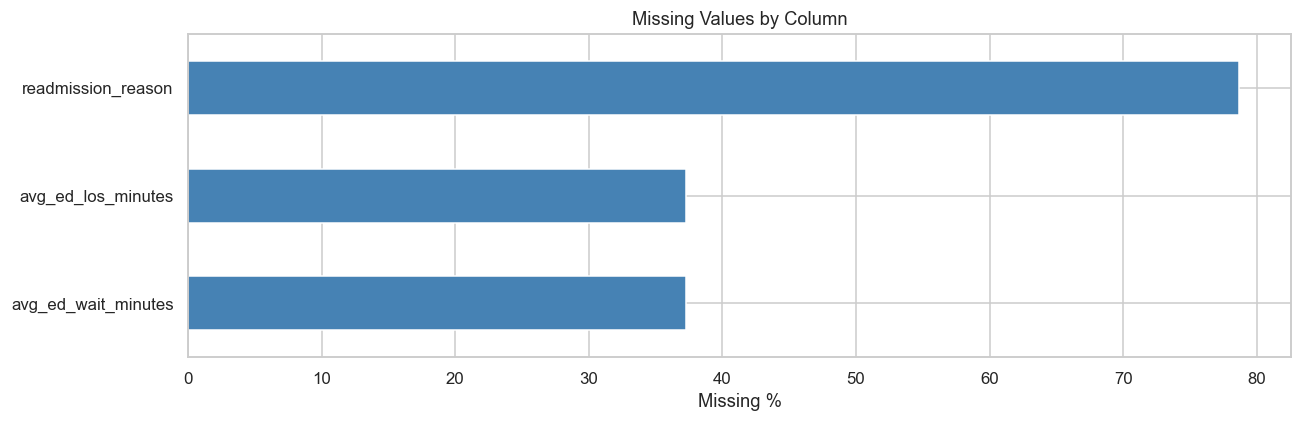

In [27]:
# --- Missing Values ---
missing = master_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(master_df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})

print(f"Columns with missing values: {len(missing_df)} / {master_df.shape[1]}\n")
print(missing_df.to_string())

# Visualise
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_df) * 0.4)))
    missing_df["Missing %"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column")
    plt.tight_layout()
    plt.show()


In [28]:
# --- Descriptive Statistics ---
master_df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
admission_id,8500,8500,ADM-0000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,8500,3636,PAT-004269,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_date,8500,1725,2021-07-27,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discharge_date,8500,1739,2022-09-03,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_of_stay_days,8500.0,NaN,NaN,NaN,5.844588,4.89739,1.0,3.0,4.0,8.0,45.0
...,...,...,...,...,...,...,...,...,...,...,...
low_social_support,8500.0,NaN,NaN,NaN,0.296353,0.456675,0.0,0.0,0.0,1.0,1.0
num_ed_visits,8500.0,NaN,NaN,NaN,1.202706,1.377792,0.0,0.0,1.0,2.0,11.0
num_ed_admissions,8500.0,NaN,NaN,NaN,0.322941,0.620333,0.0,0.0,0.0,1.0,5.0
avg_ed_wait_minutes,5335.0,NaN,NaN,NaN,68.336907,64.117866,0.0,25.0,51.0,89.4,563.0


---
## 2. Univariate Analysis

### 2a. Target Variable — `readmitted_within_30d`


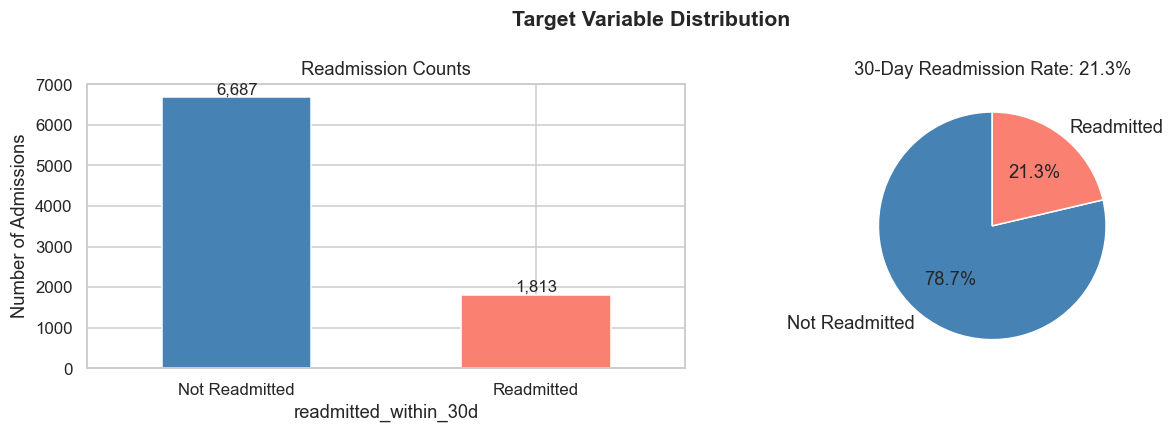


Class balance:
readmitted_within_30d
Not Readmitted    6687
Readmitted        1813

Readmission rate: 21.33%


In [29]:
TARGET = "readmitted_within_30d"

counts = master_df[TARGET].value_counts().rename({0: "Not Readmitted", 1: "Readmitted"})
rate   = master_df[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
counts.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"], edgecolor="white", rot=0)
axes[0].set_title("Readmission Counts")
axes[0].set_ylabel("Number of Admissions")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=11)

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["steelblue", "salmon"], startangle=90, textprops={"fontsize": 12})
axes[1].set_title(f"30-Day Readmission Rate: {rate:.1%}")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nClass balance:\n{counts.to_string()}")
print(f"\nReadmission rate: {rate:.2%}")


### 2b. Numeric Features — Distributions


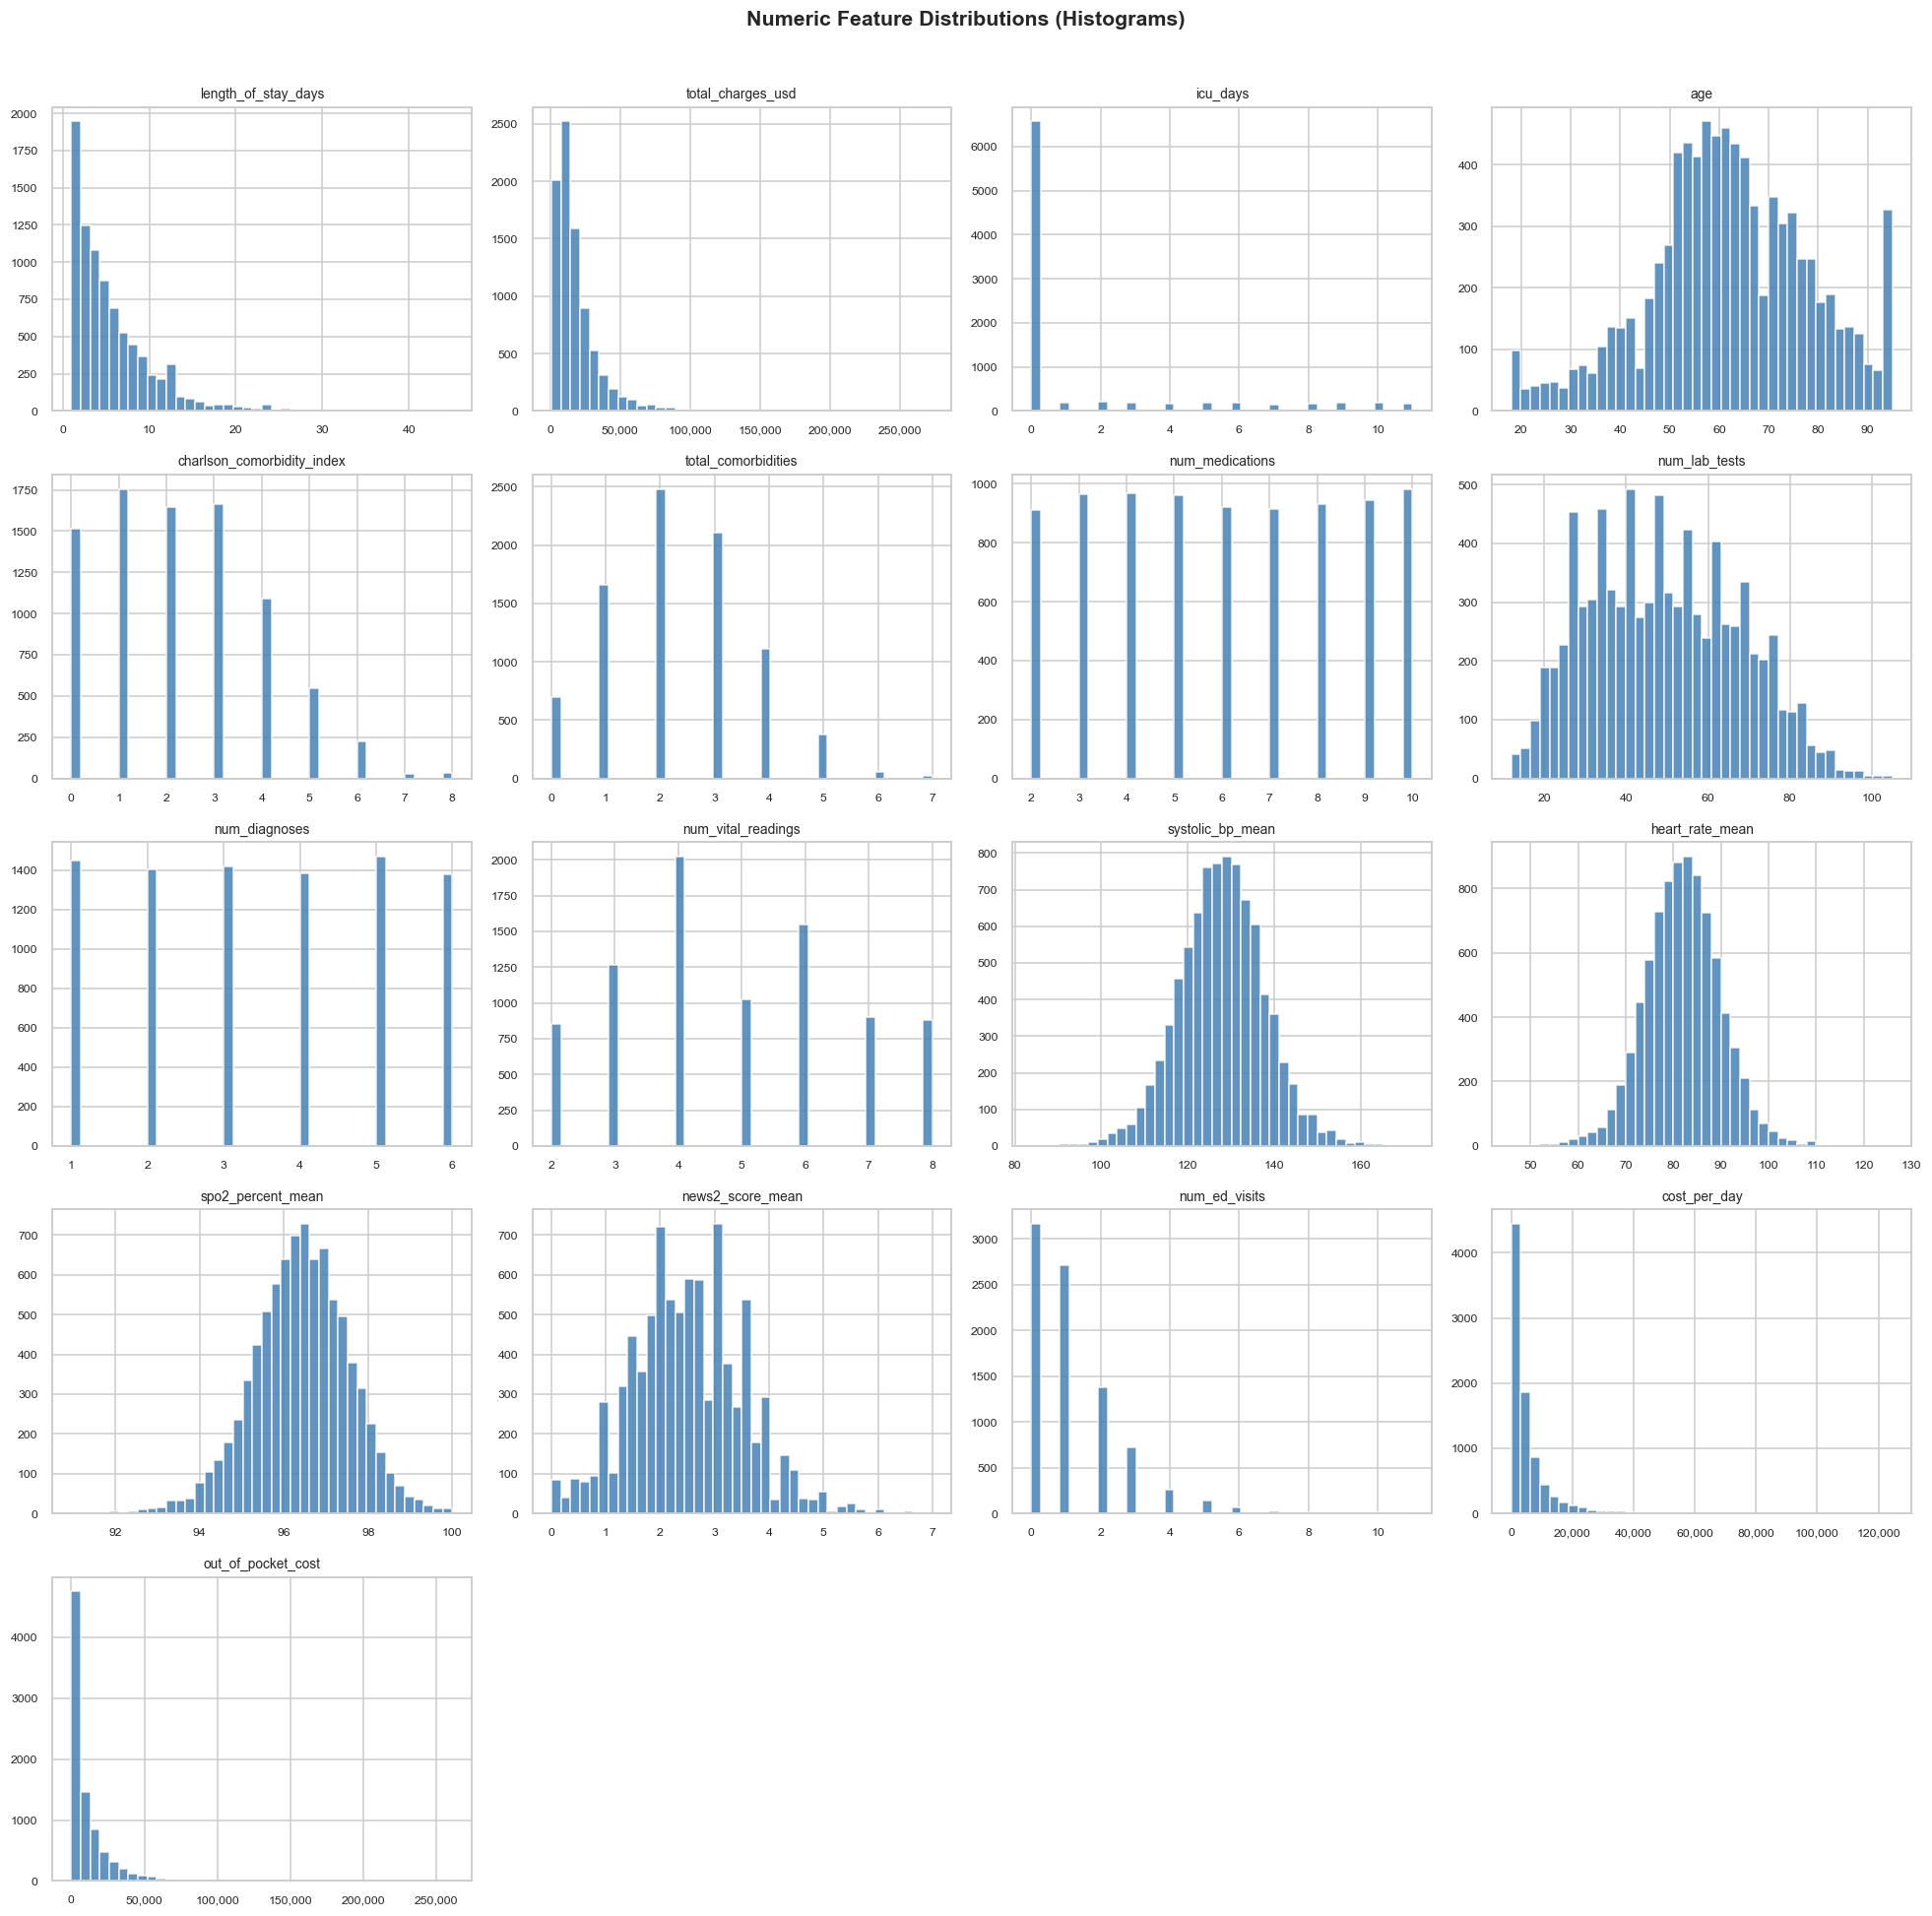

In [30]:
# Select key numeric features to profile
key_numeric = [
    "length_of_stay_days", "total_charges_usd", "icu_days",
    "age", "charlson_comorbidity_index", "total_comorbidities",
    "num_medications", "num_lab_tests", "num_diagnoses",
    "num_vital_readings", "systolic_bp_mean", "heart_rate_mean",
    "spo2_percent_mean", "news2_score_mean", "num_ed_visits",
    "cost_per_day", "out_of_pocket_cost",
]
key_numeric = [c for c in key_numeric if c in master_df.columns]

n_cols = 4
n_rows = -(-len(key_numeric) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    data = master_df[col].dropna()
    axes[i].hist(data, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=8)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions (Histograms)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


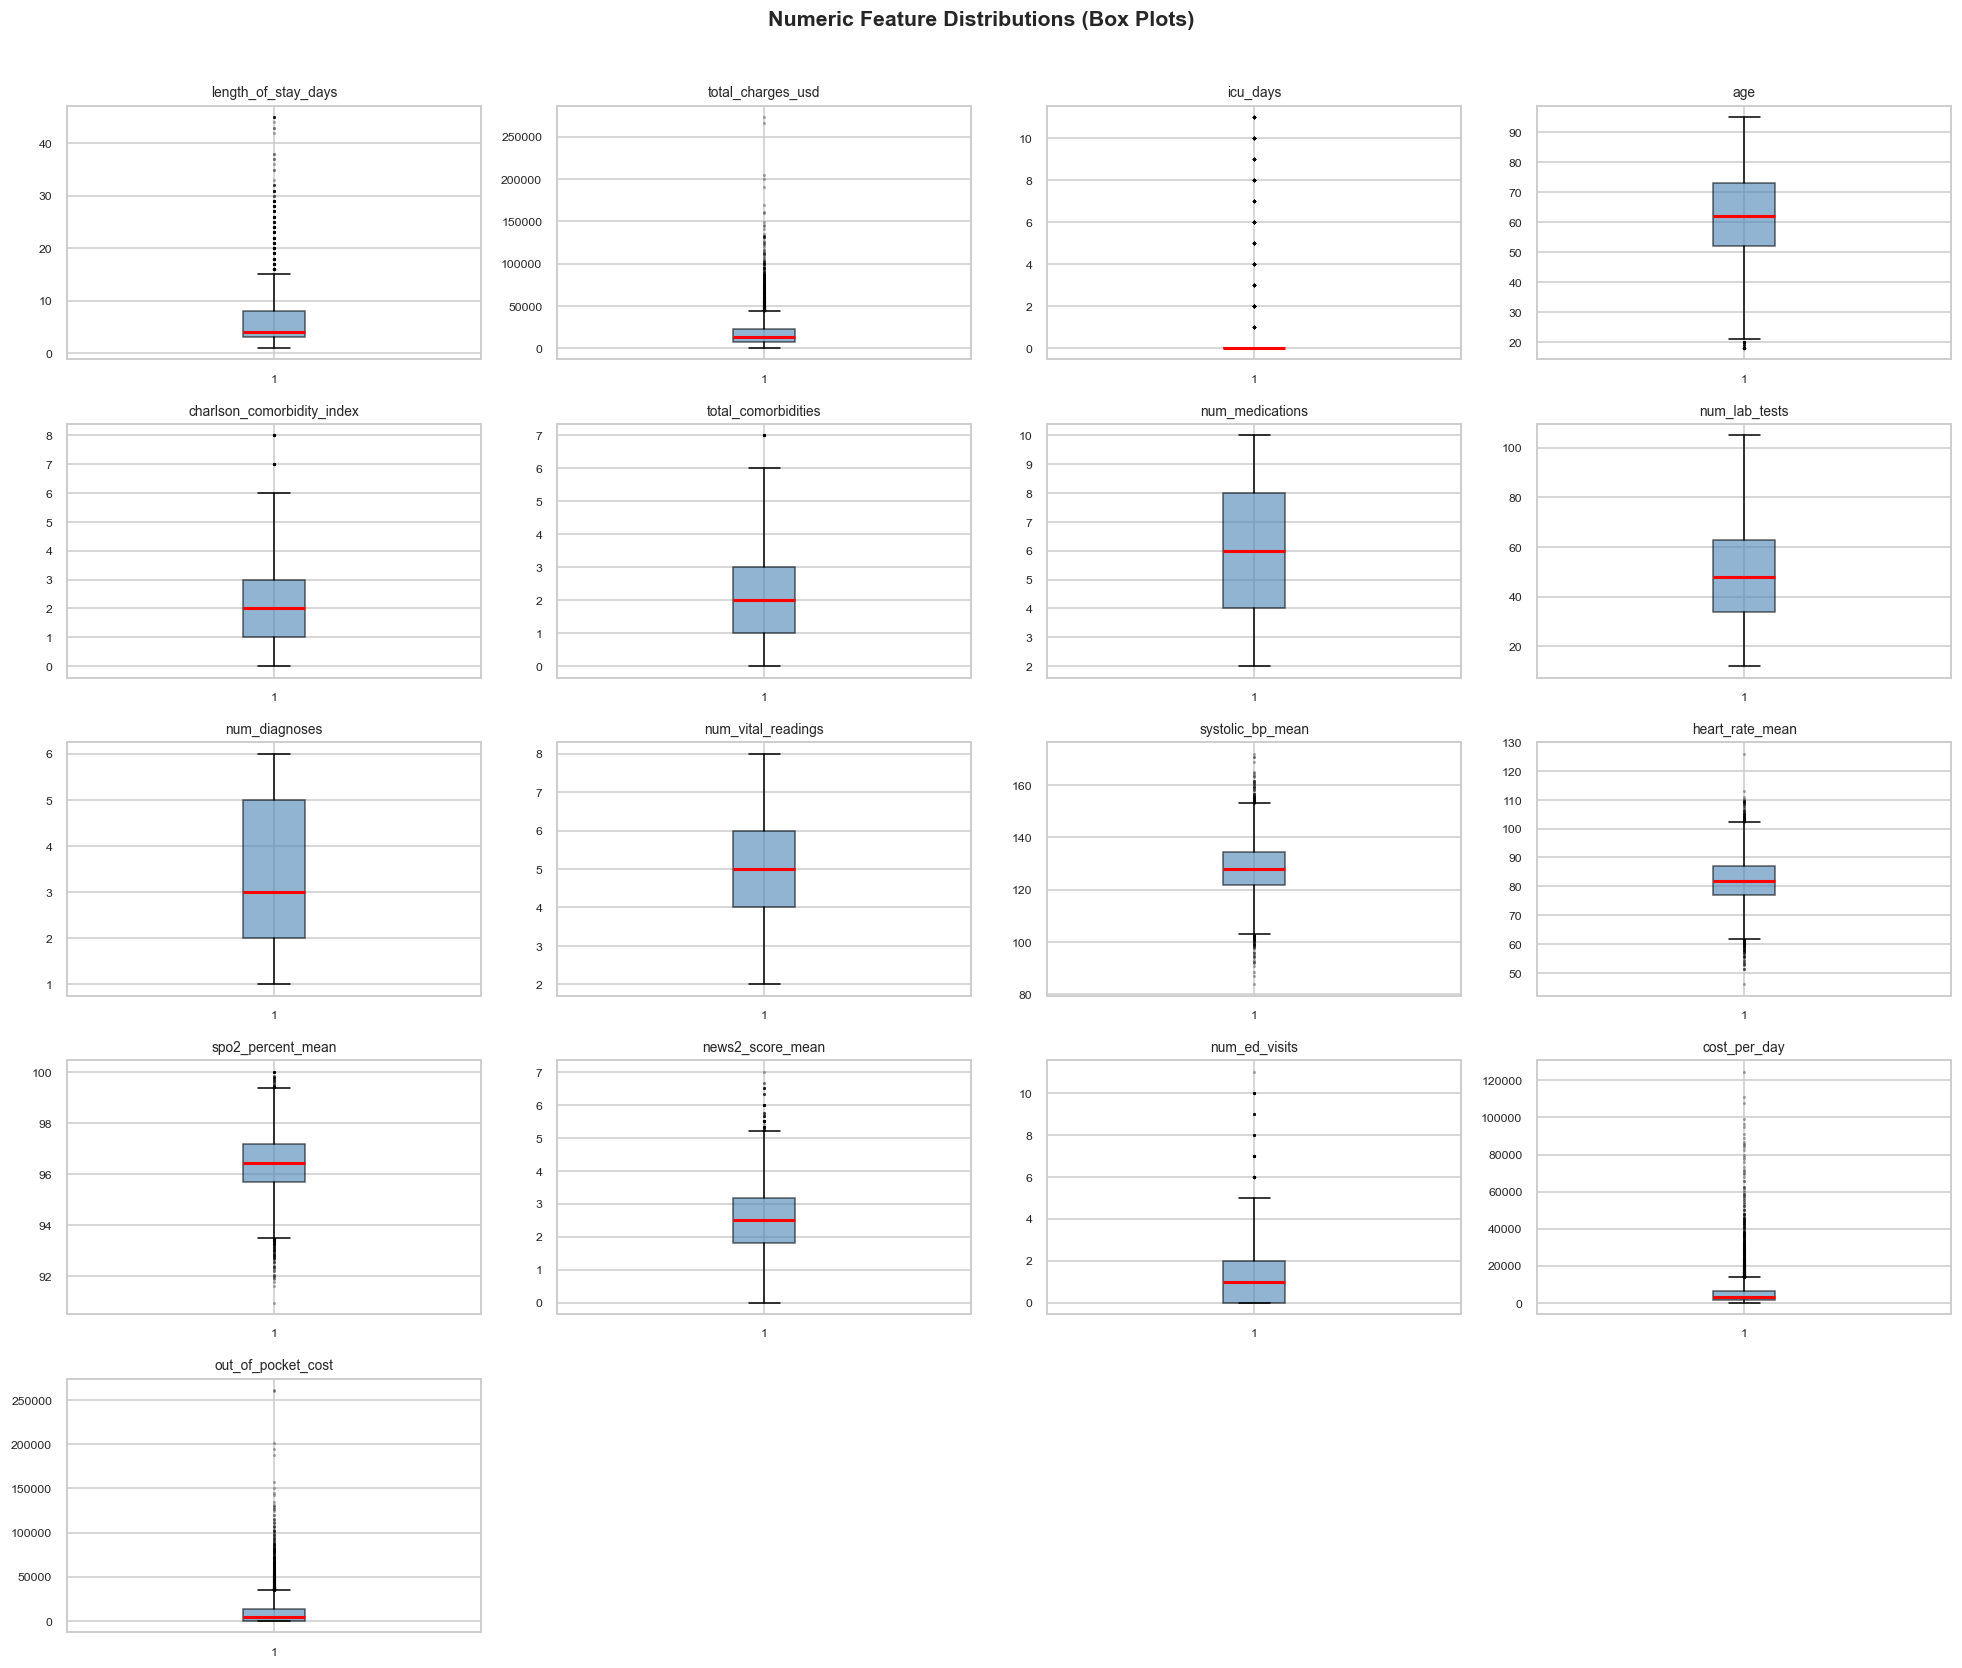

In [31]:
# Box plots for the same numeric features (spot skewness & outliers)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    axes[i].boxplot(master_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6),
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions (Box Plots)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 2c. Categorical Features — Value Counts


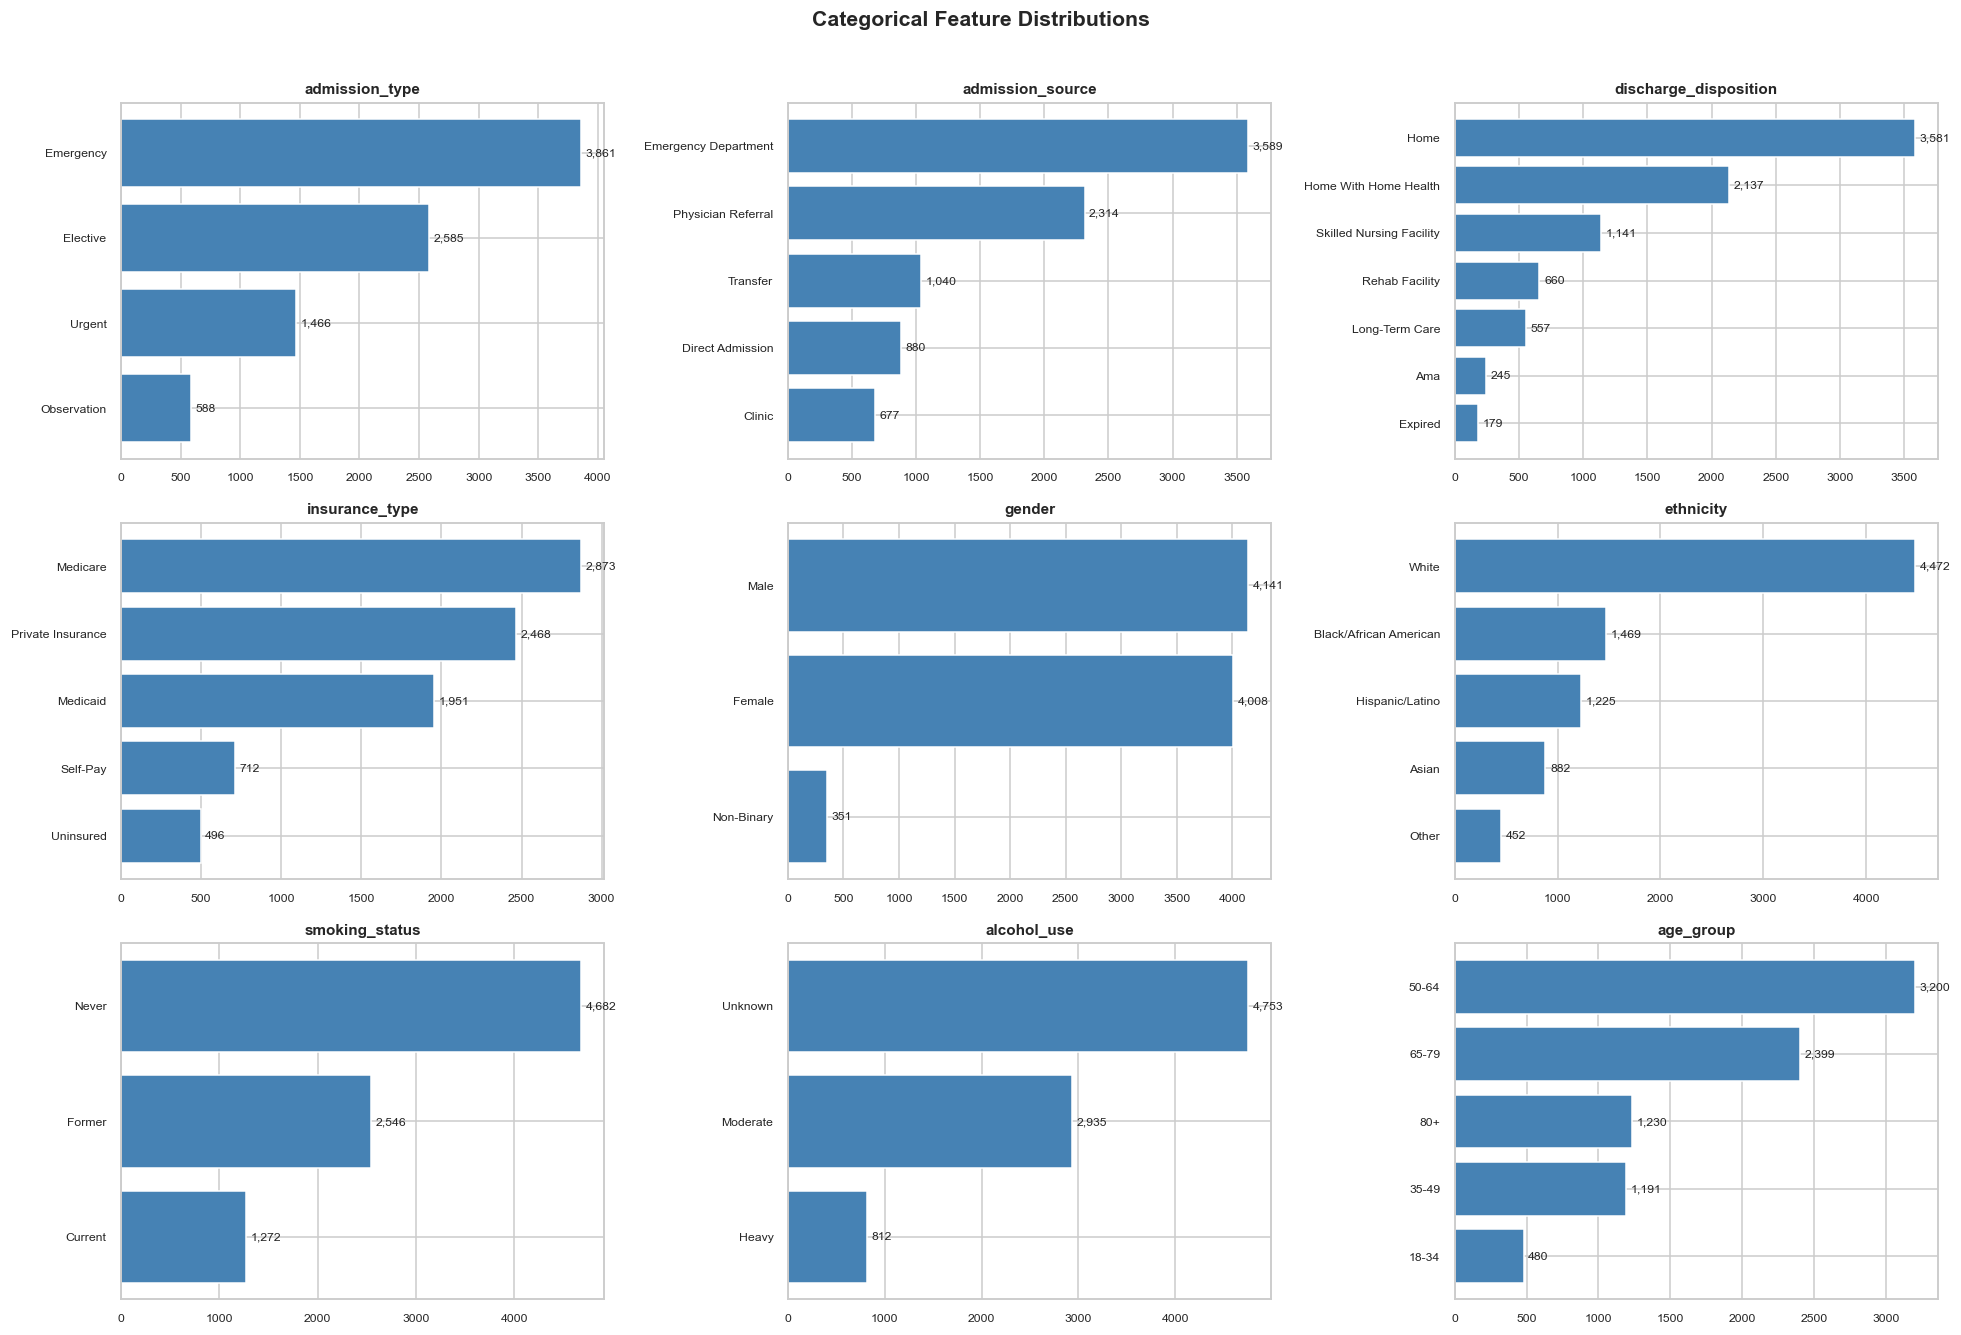

In [32]:
key_categorical = [
    "admission_type", "admission_source", "discharge_disposition",
    "insurance_type", "gender", "ethnicity",
    "smoking_status", "alcohol_use", "age_group",
]
key_categorical = [c for c in key_categorical if c in master_df.columns]

n_cols = 3
n_rows = -(-len(key_categorical) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    vc = master_df[col].value_counts()
    axes[i].barh(vc.index.astype(str)[::-1], vc.values[::-1], color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=8)
    for bar, val in zip(axes[i].patches, vc.values[::-1]):
        axes[i].text(bar.get_width() + vc.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:,}", va="center", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


---
## 3. Bivariate Analysis

### 3a. Numeric Features vs Target (Box Plots)


IndexError: index 9 is out of bounds for axis 0 with size 9

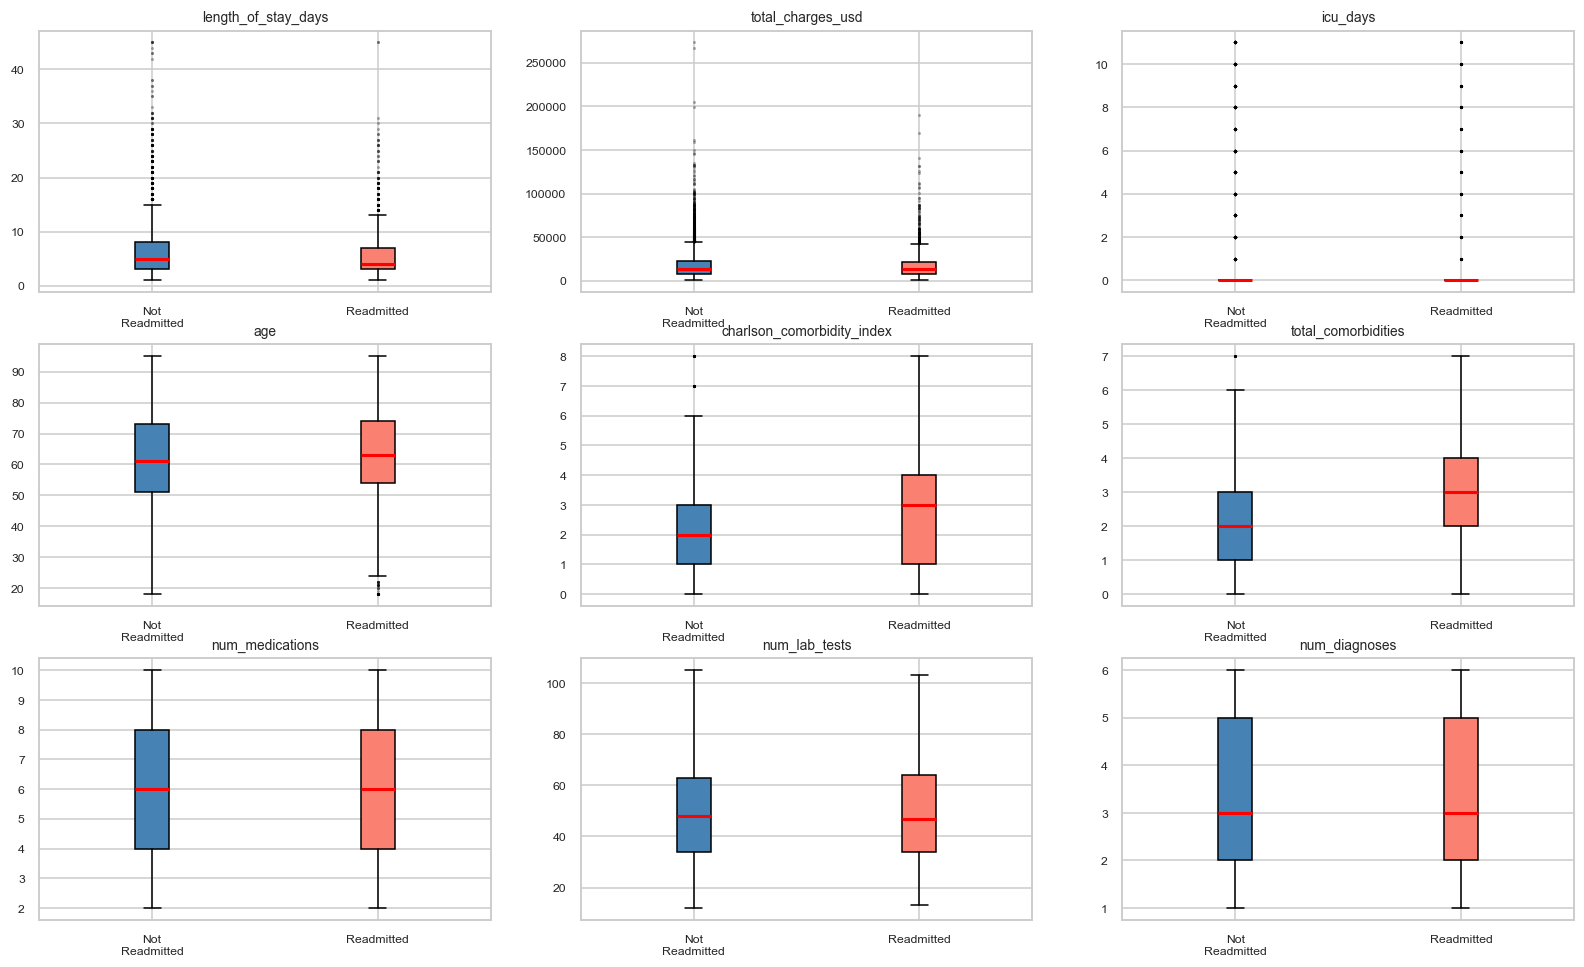

In [33]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    data0 = master_df.loc[master_df[TARGET] == 0, col].dropna()
    data1 = master_df.loc[master_df[TARGET] == 1, col].dropna()
    bp = axes[i].boxplot(
        [data0, data1], patch_artist=True, vert=True,
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("salmon")
    axes[i].set_xticklabels(["Not\nReadmitted", "Readmitted"], fontsize=8)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features vs 30-Day Readmission", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 3b. Categorical Features vs Target — Readmission Rates


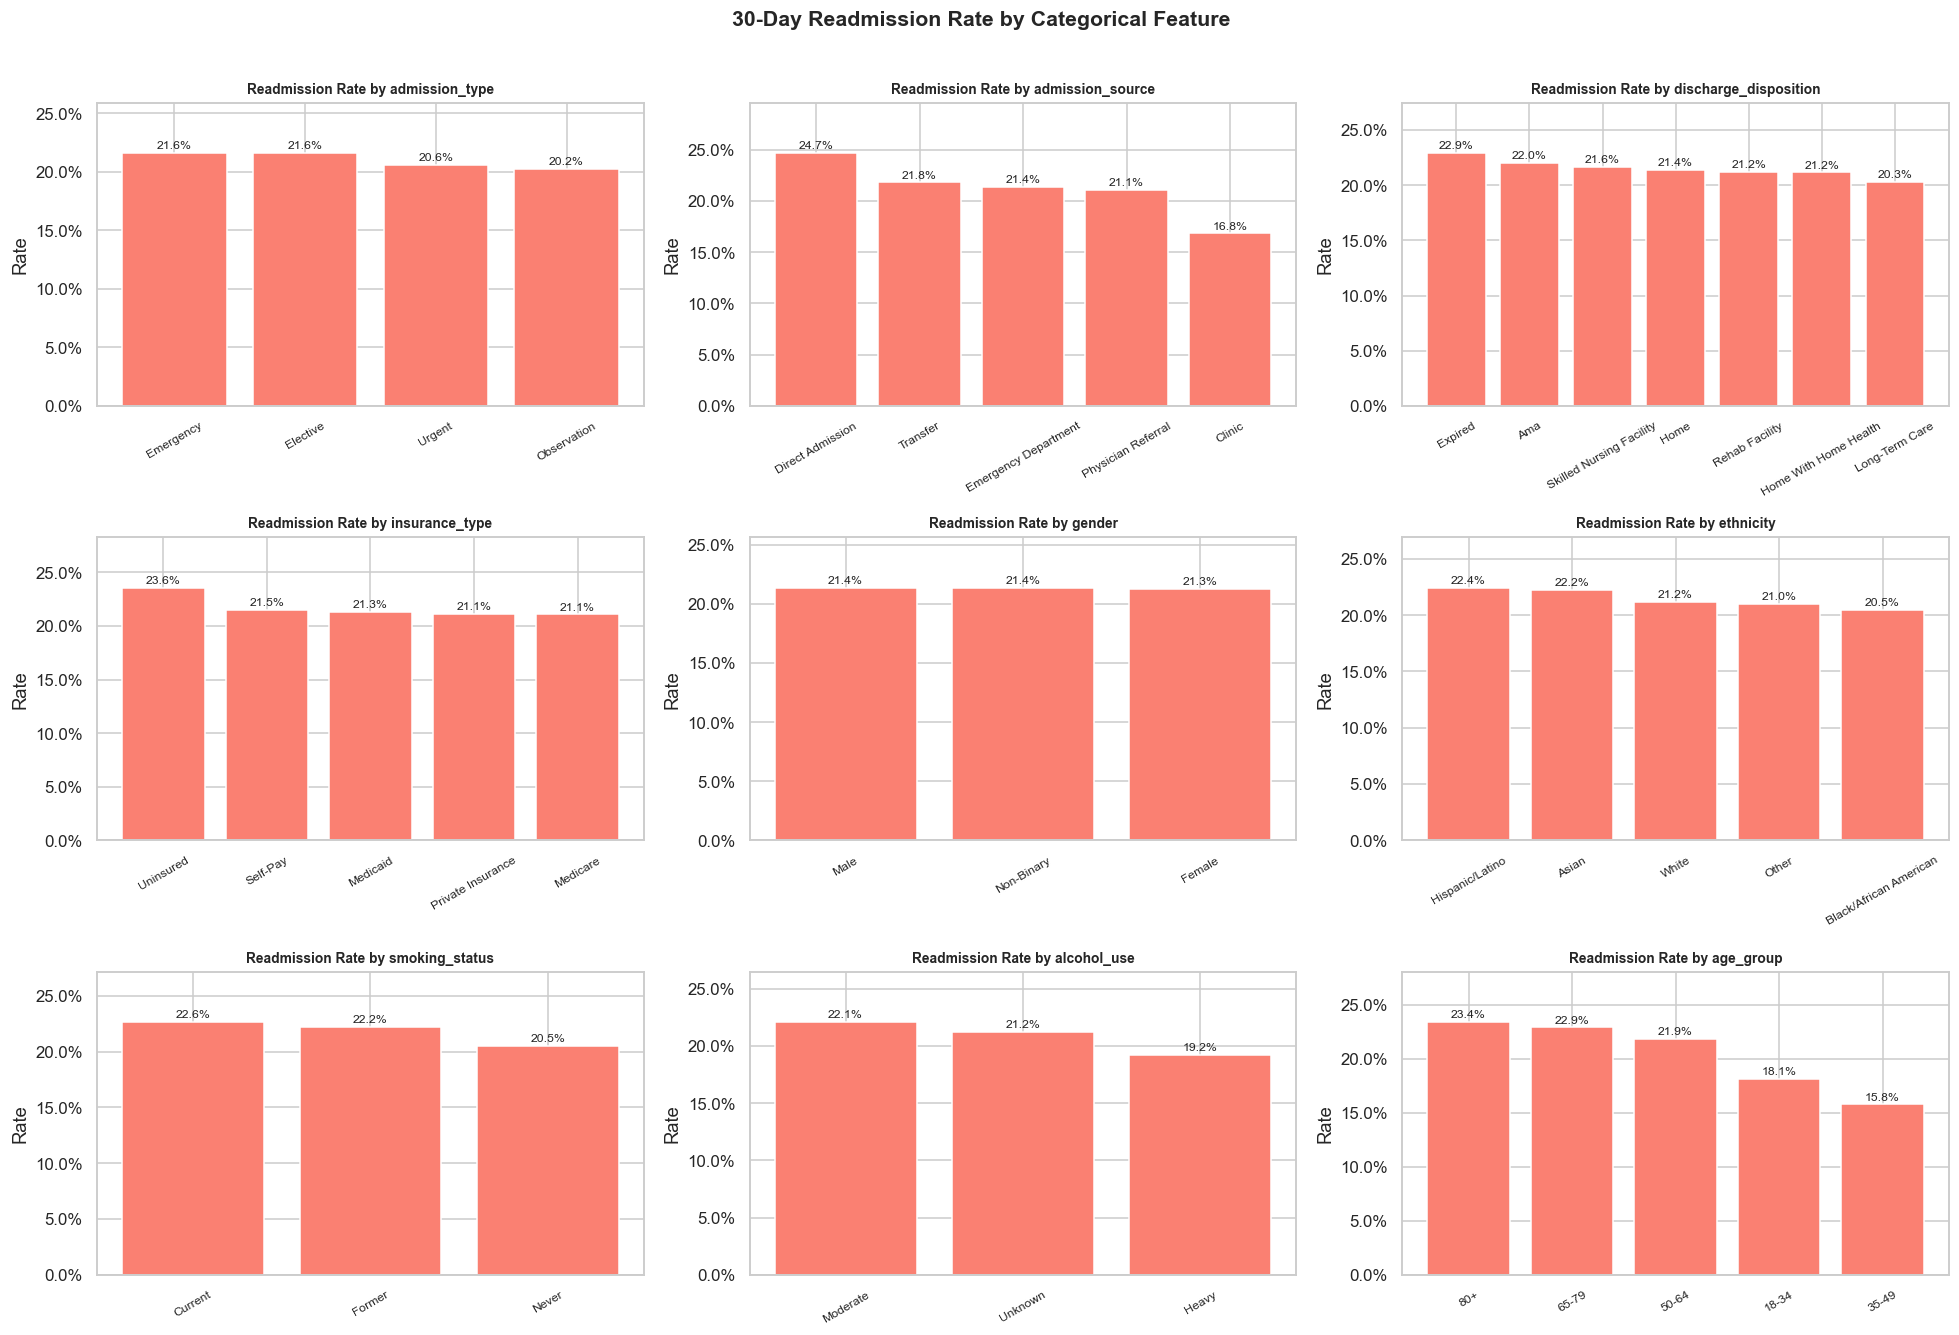

In [34]:
n_cols_cat = 3
n_rows_cat = -(-len(key_categorical) // n_cols_cat)

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(18, n_rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(key_categorical):
    rate_by_cat = (
        master_df.groupby(col)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    rate_by_cat.columns = [col, "readmission_rate"]
    bars = axes[i].bar(
        rate_by_cat[col].astype(str),
        rate_by_cat["readmission_rate"],
        color="salmon", edgecolor="white",
    )
    axes[i].set_title(f"Readmission Rate by {col}", fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Rate")
    axes[i].set_ylim(0, rate_by_cat["readmission_rate"].max() * 1.2)
    axes[i].tick_params(axis="x", rotation=30, labelsize=8)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for bar, val in zip(bars, rate_by_cat["readmission_rate"]):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                     f"{val:.1%}", ha="center", va="bottom", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("30-Day Readmission Rate by Categorical Feature", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 3c. Point-Biserial Correlation — Numeric Features with Target


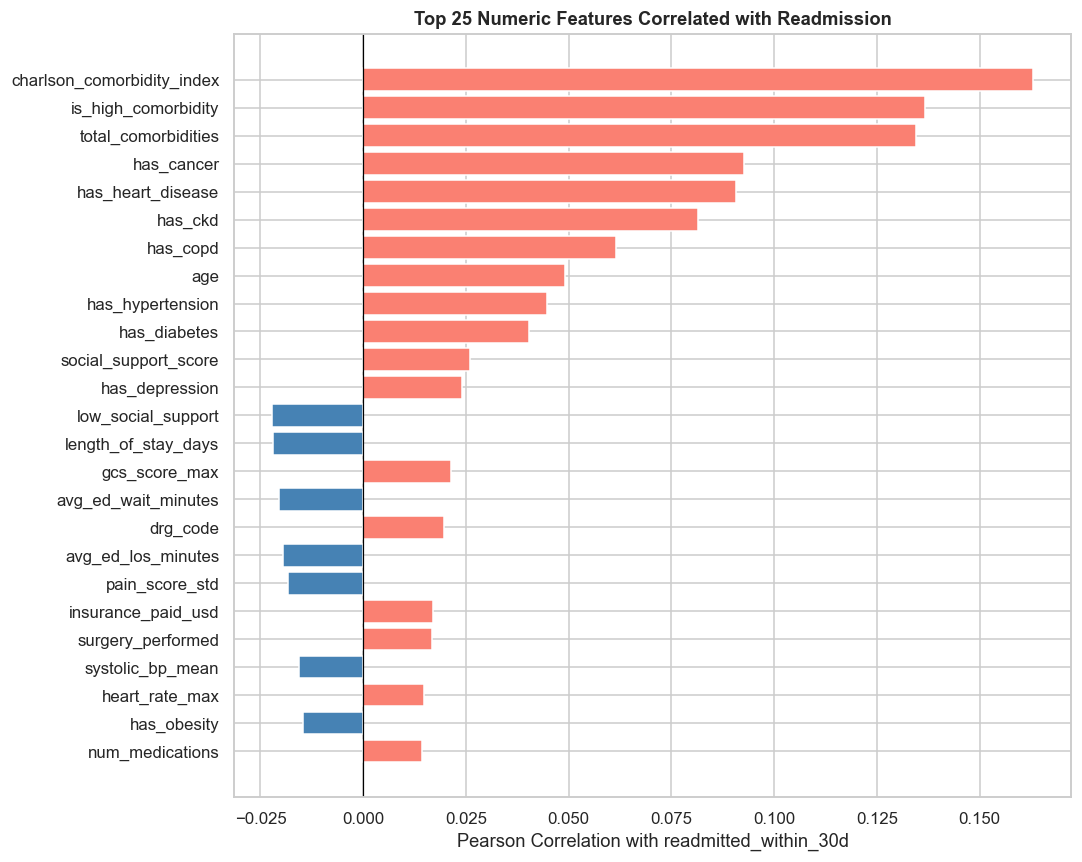

charlson_comorbidity_index    0.163073
is_high_comorbidity           0.136737
total_comorbidities           0.134601
has_cancer                    0.092625
has_heart_disease             0.090701
has_ckd                       0.081532
has_copd                      0.061542
age                           0.049189
has_hypertension              0.044849
has_diabetes                  0.040430
social_support_score          0.025888
has_depression                0.024144
low_social_support           -0.022194
length_of_stay_days          -0.021831
gcs_score_max                 0.021406
avg_ed_wait_minutes          -0.020527
drg_code                      0.019729
avg_ed_los_minutes           -0.019432
pain_score_std               -0.018357
insurance_paid_usd            0.016989
surgery_performed             0.016779
systolic_bp_mean             -0.015580
heart_rate_max                0.014879
has_obesity                  -0.014751
num_medications               0.014436


In [35]:
numeric_cols = master_df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

corr_with_target = (
    master_df[numeric_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .head(25)
)

colors = ["salmon" if v > 0 else "steelblue" for v in corr_with_target]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with readmitted_within_30d")
ax.set_title("Top 25 Numeric Features Correlated with Readmission", fontweight="bold")
plt.tight_layout()
plt.show()

print(corr_with_target.to_string())


---
## 4. Multivariate Analysis

### 4a. Correlation Heatmap (Top Numeric Features)


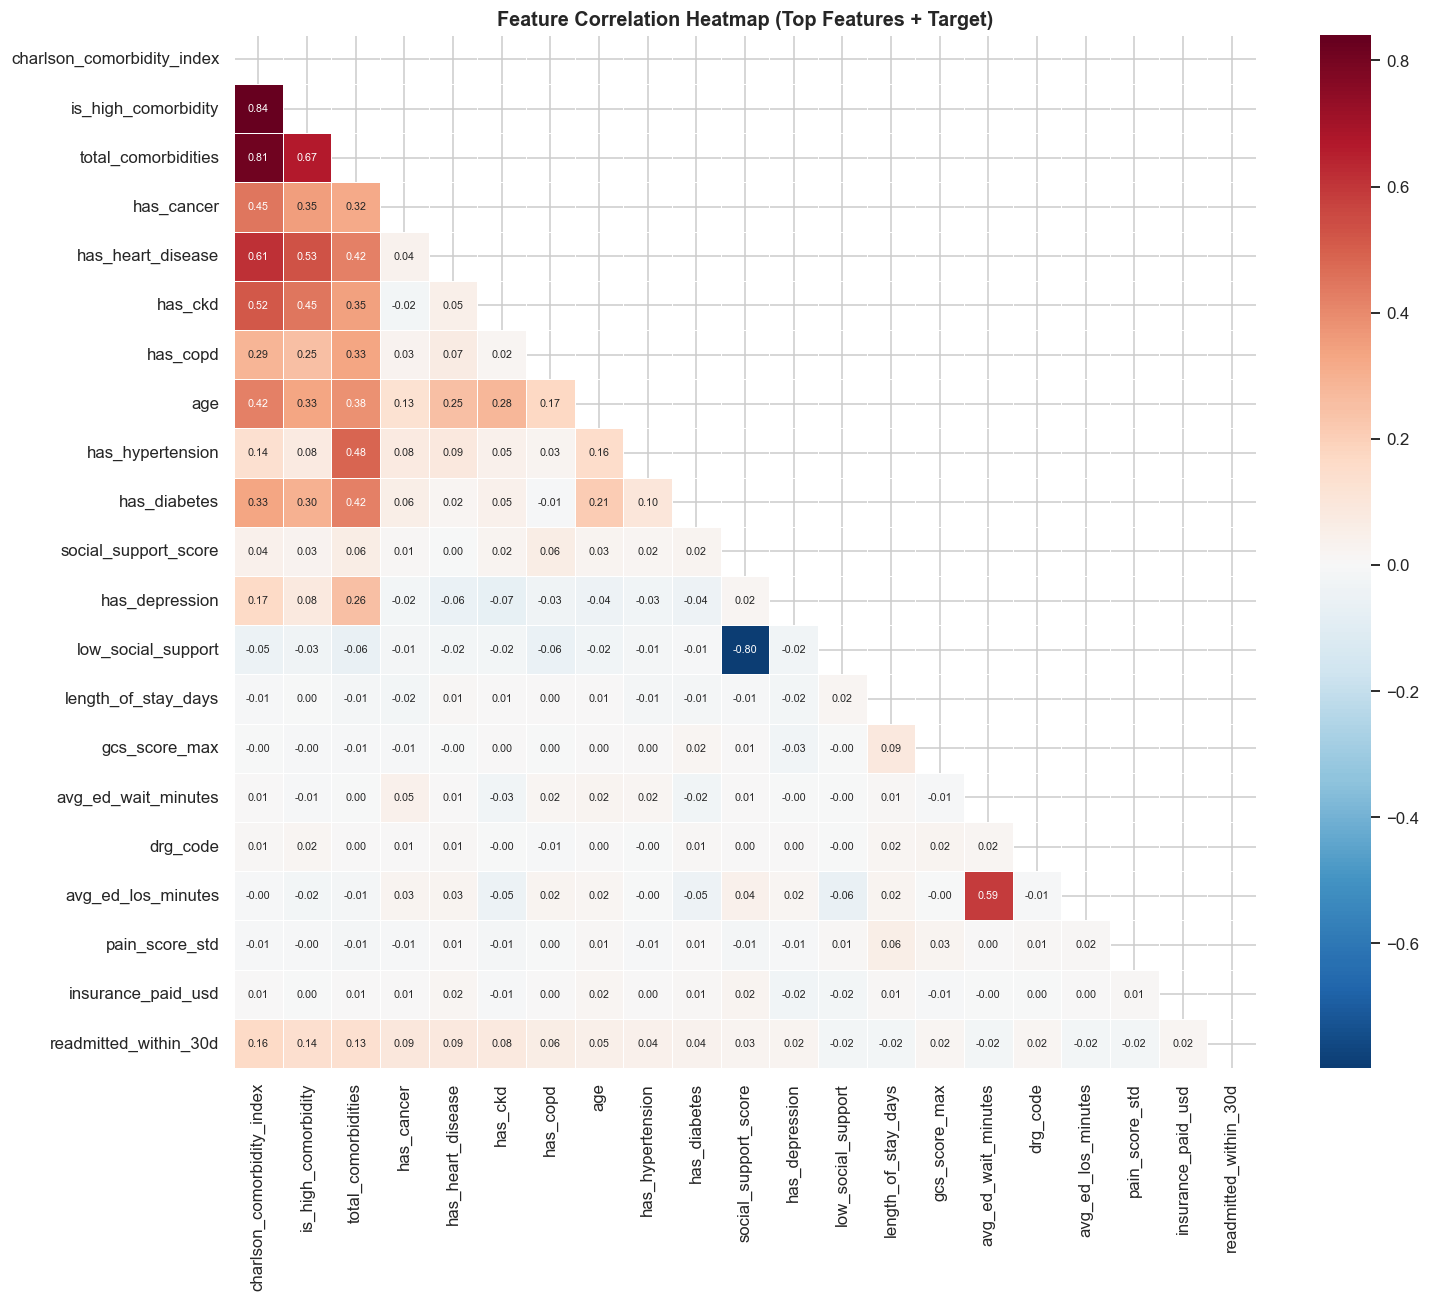

In [36]:
# Use top correlated features + target for the heatmap
top_features = corr_with_target.head(20).index.tolist() + [TARGET]
corr_matrix = master_df[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, linewidths=0.5,
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title("Feature Correlation Heatmap (Top Features + Target)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4b. Pairplot — Key Clinical Features by Readmission Status


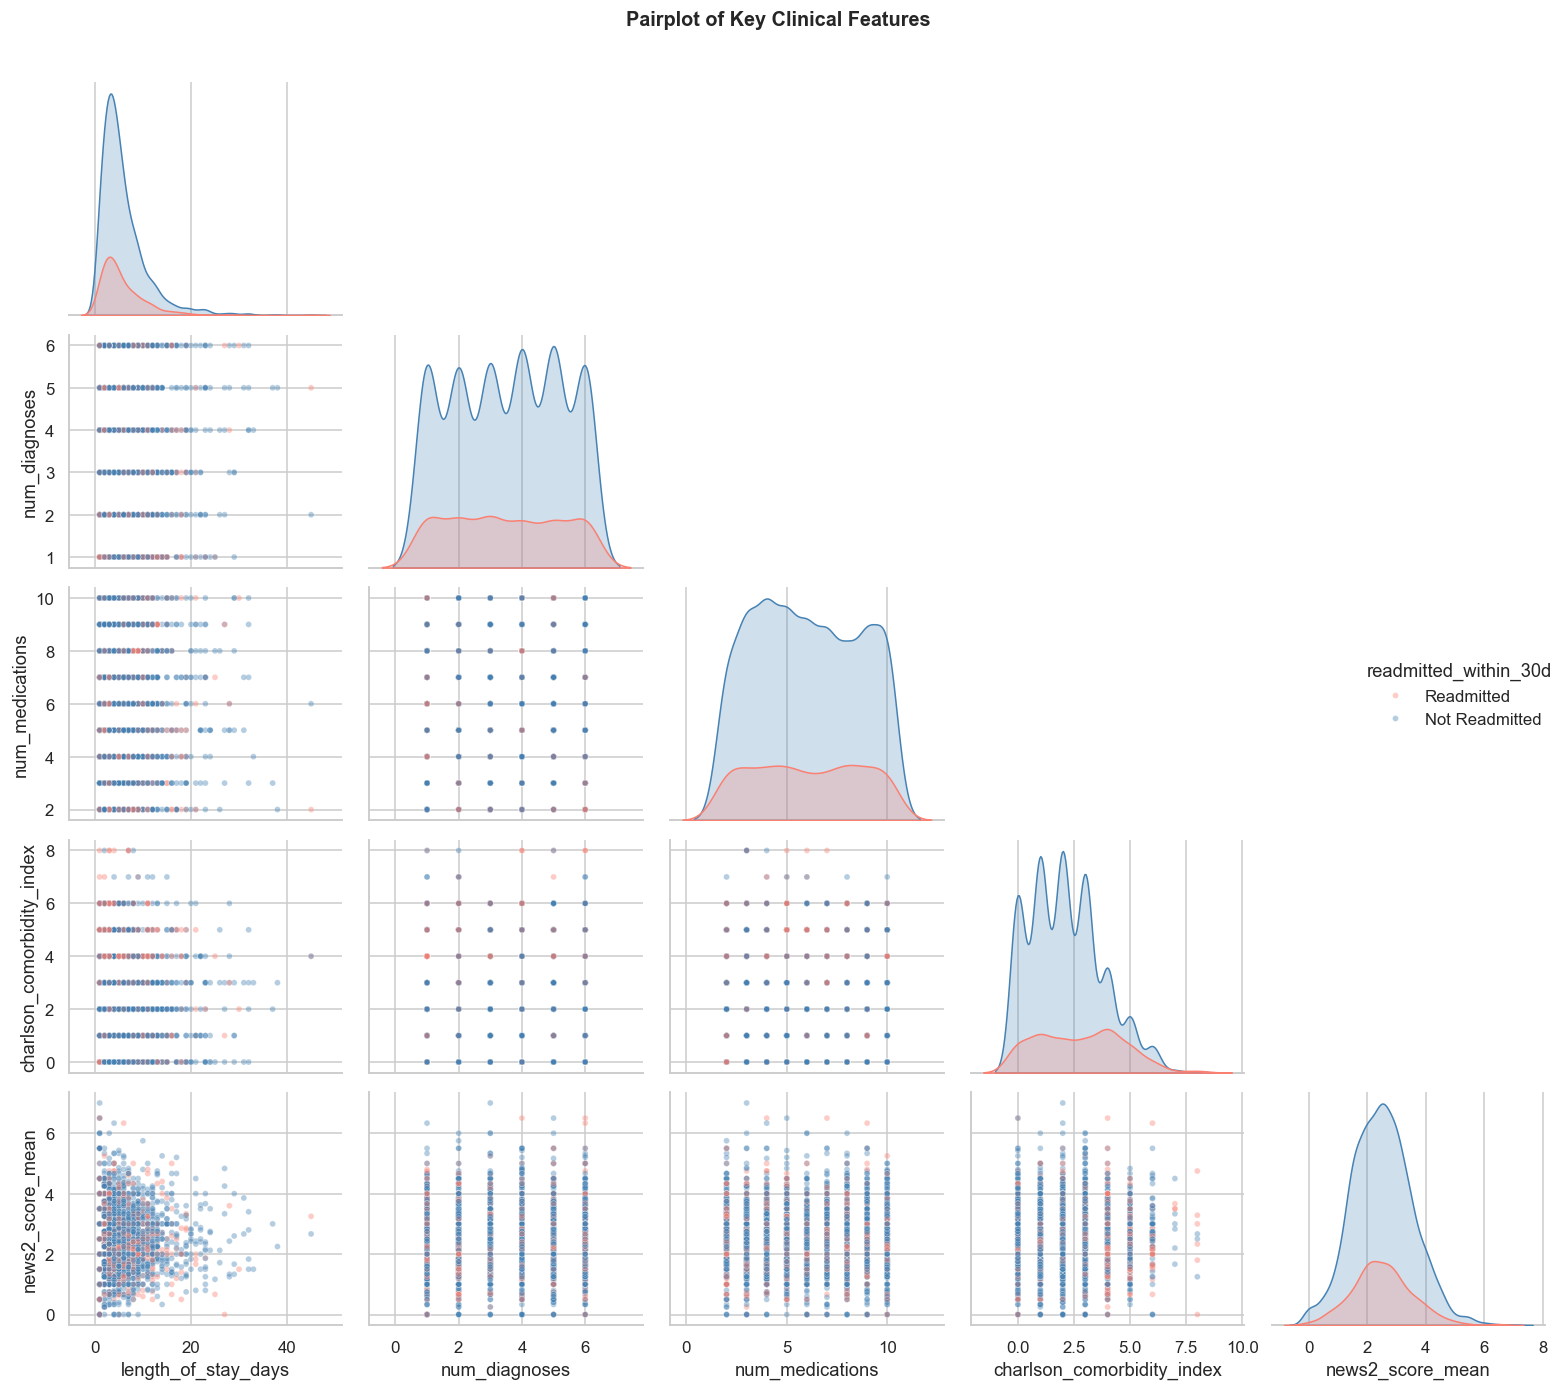

In [37]:
pair_features = [
    "length_of_stay_days", "num_diagnoses", "num_medications",
    "charlson_comorbidity_index", "news2_score_mean", TARGET,
]
pair_features = [c for c in pair_features if c in master_df.columns]

pair_df = master_df[pair_features].dropna().sample(min(3000, len(master_df)), random_state=42)
pair_df[TARGET] = pair_df[TARGET].map({0: "Not Readmitted", 1: "Readmitted"})

g = sns.pairplot(
    pair_df,
    hue=TARGET,
    palette={"Not Readmitted": "steelblue", "Readmitted": "salmon"},
    plot_kws=dict(alpha=0.4, s=15),
    diag_kind="kde",
    corner=True,
)
g.figure.suptitle("Pairplot of Key Clinical Features", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 4c. Comorbidity Profile vs Readmission


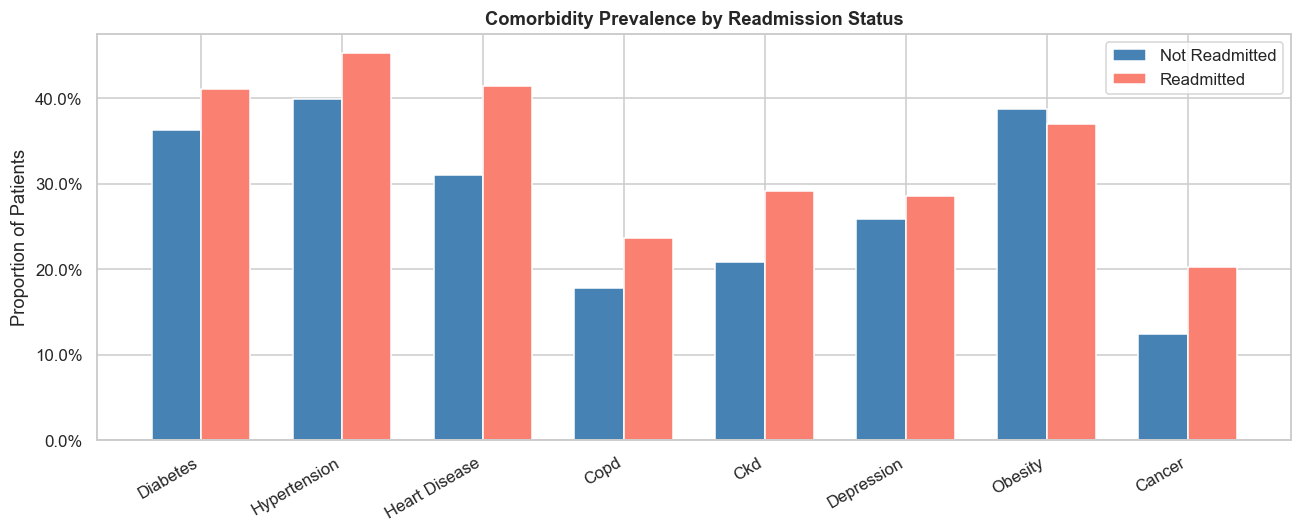

In [38]:
comorbidity_cols = [
    "has_diabetes", "has_hypertension", "has_heart_disease",
    "has_copd", "has_ckd", "has_depression", "has_obesity", "has_cancer",
]
comorbidity_cols = [c for c in comorbidity_cols if c in master_df.columns]

readmission_by_comorbidity = (
    master_df.groupby(TARGET)[comorbidity_cols]
    .mean()
    .T
    .rename(columns={0: "Not Readmitted", 1: "Readmitted"})
)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(readmission_by_comorbidity))
width = 0.35

ax.bar(x - width/2, readmission_by_comorbidity["Not Readmitted"],
       width, label="Not Readmitted", color="steelblue", edgecolor="white")
ax.bar(x + width/2, readmission_by_comorbidity["Readmitted"],
       width, label="Readmitted", color="salmon", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(
    [c.replace("has_", "").replace("_", " ").title() for c in readmission_by_comorbidity.index],
    rotation=30, ha="right",
)
ax.set_ylabel("Proportion of Patients")
ax.set_title("Comorbidity Prevalence by Readmission Status", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()


### 4d. Length of Stay × Total Charges × Readmission (Scatter)


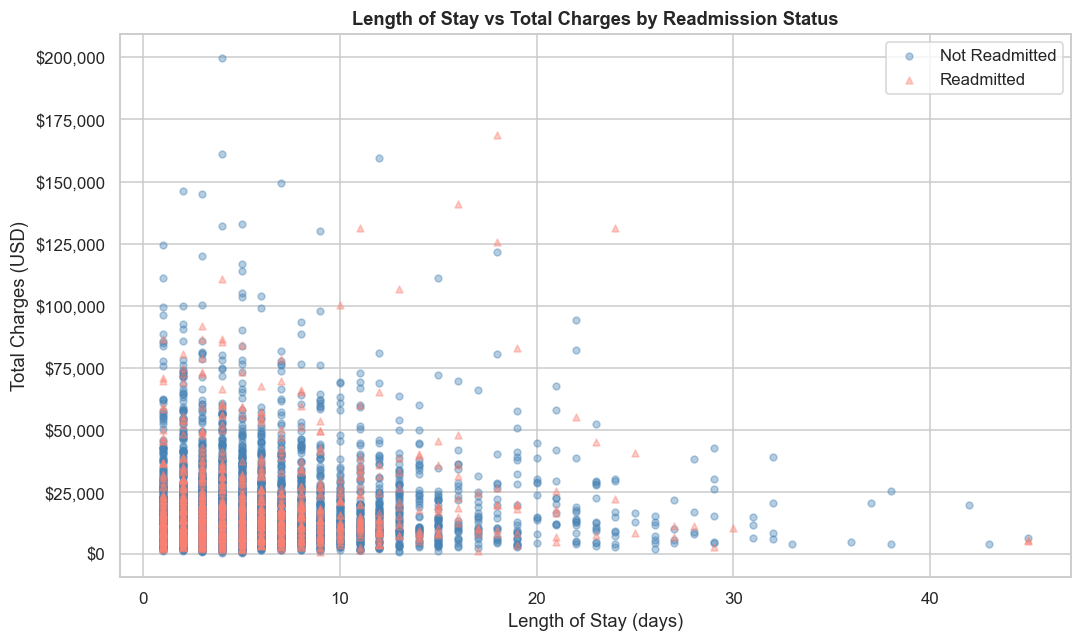

In [39]:
scatter_df = master_df[["length_of_stay_days", "total_charges_usd", TARGET]].dropna()
scatter_df = scatter_df.sample(min(5000, len(scatter_df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for label, color, marker in [(0, "steelblue", "o"), (1, "salmon", "^")]:
    sub = scatter_df[scatter_df[TARGET] == label]
    ax.scatter(
        sub["length_of_stay_days"], sub["total_charges_usd"],
        c=color, alpha=0.4, s=20, marker=marker,
        label="Not Readmitted" if label == 0 else "Readmitted",
    )

ax.set_xlabel("Length of Stay (days)")
ax.set_ylabel("Total Charges (USD)")
ax.set_title("Length of Stay vs Total Charges by Readmission Status", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


### 4e. Readmission Rate by Age Group × Insurance Type (Heatmap)


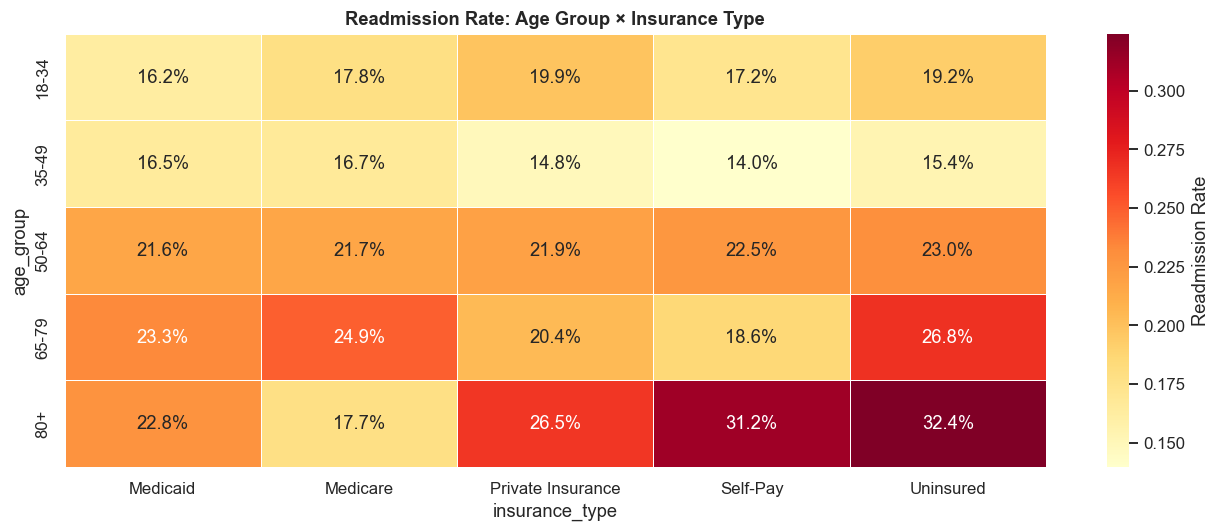

In [40]:
if "age_group" in master_df.columns and "insurance_type" in master_df.columns:
    pivot = (
        master_df.groupby(["age_group", "insurance_type"])[TARGET]
        .mean()
        .unstack("insurance_type")
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt=".1%", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "Readmission Rate"}, ax=ax)
    ax.set_title("Readmission Rate: Age Group × Insurance Type", fontweight="bold")
    plt.tight_layout()
    plt.show()


### 4f. Readmission Rate by Number of Comorbidities


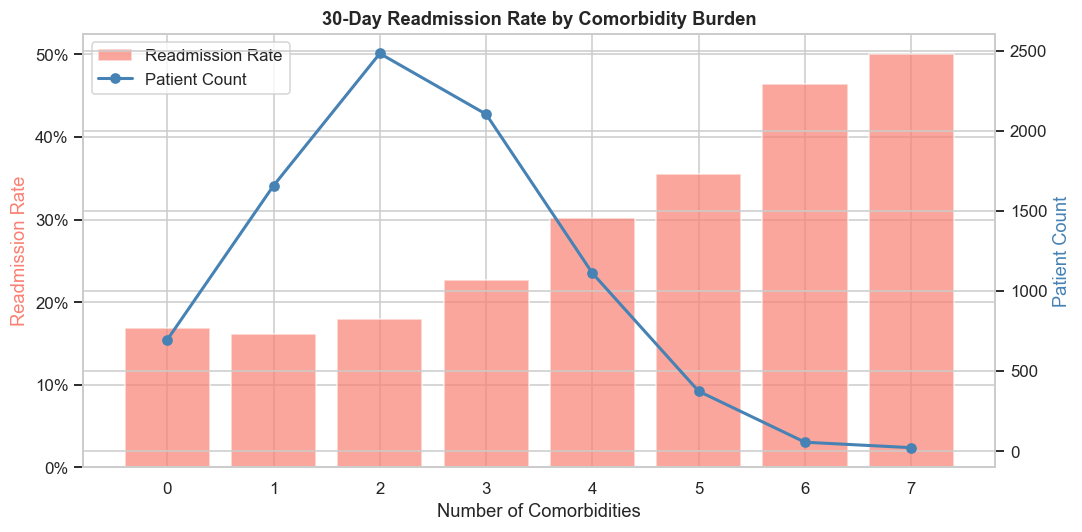

In [41]:
if "total_comorbidities" in master_df.columns:
    comorbidity_rate = (
        master_df.groupby("total_comorbidities")[TARGET]
        .agg(["mean", "count"])
        .reset_index()
    )
    comorbidity_rate.columns = ["total_comorbidities", "readmission_rate", "n"]

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.bar(comorbidity_rate["total_comorbidities"], comorbidity_rate["readmission_rate"],
            color="salmon", alpha=0.7, label="Readmission Rate")
    ax2.plot(comorbidity_rate["total_comorbidities"], comorbidity_rate["n"],
             color="steelblue", marker="o", linewidth=2, label="Patient Count")

    ax1.set_xlabel("Number of Comorbidities")
    ax1.set_ylabel("Readmission Rate", color="salmon")
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax2.set_ylabel("Patient Count", color="steelblue")
    ax1.set_title("30-Day Readmission Rate by Comorbidity Burden", fontweight="bold")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()
